# Bacterial Growth Analysis

## Exploratory Data Analysis

### Objective

The objective of this stage is to explore bacterial population growth
patterns across time, strains, and temperature conditions.

The analysis focuses on identifying relevant patterns and differences
in bacterial growth behaviour before applying statistical methods.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/bacteria_growth_clean.csv")

##  Dataset Overview

In [ ]:
print(f"Observations: {len(df)}")
print(f"Experiments: {df['experiment_id'].nunique()}")
print(f"Strains: {df['strain'].nunique()}")
print(f"Temperatures: {df['temperature'].nunique()}")
print(f"Time range: {df['hour'].min()}–{df['hour'].max()} hours")

In [ ]:
df.groupby(["strain", "temperature"]).agg(
    experiments=("experiment_id", "nunique"),
    observations=("population", "count")
)

### Findings

The cleaned dataset contains 5,880 observations from 120 experiments.
The experiments cover three bacterial strains and four temperature
conditions, with ten experiments for each strain-temperature combination.

All experiments span from hour 0 to hour 48. The number of available
population observations varies slightly across experimental conditions
due to missing population values.

## Population Distribution

The distribution of bacterial population is examined to understand its
overall range, central tendency, and variability before analysing growth
trajectories over time.

In [ ]:
df["population"].describe()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["population"].dropna(),
    bins=40,
    edgecolor="black"
)

plt.xlabel("Population")
plt.ylabel("Frequency")
plt.title("Distribution of Bacterial Population")

plt.show()

In [ ]:
df["population"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

### Findings

The population distribution is strongly right-skewed. Most observations
are concentrated at relatively low population levels, while a smaller
number of observations reach substantially higher values.

The median population is 4,158.5, compared with a mean of 30,859.9,
indicating that high population values have a strong influence on the
mean.

The maximum population of 755,515 is substantially higher than the
99th percentile and will be investigated in the context of growth
trajectories rather than treated as an error based on its magnitude
alone.

## Growth Over Time

Population growth across the 48-hour observation period.

In [ ]:
sample_experiments = (
    df["experiment_id"]
    .drop_duplicates()
    .sample(6, random_state=42)
    .tolist()
)

sample_experiments

In [ ]:
plt.figure(figsize=(10, 6))

for experiment_id in sample_experiments:
    experiment = df[df["experiment_id"] == experiment_id].sort_values("hour")

    plt.plot(
        experiment["hour"],
        experiment["population"],
        label=f"Experiment {experiment_id}"
    )

plt.xlabel("Hour")
plt.ylabel("Population")
plt.title("Bacterial Population Growth Over Time")
plt.legend()

plt.show()

### Findings

The selected experiments show different population trajectories over
time, with some experiments reaching substantially higher population
levels than others.

This variability motivates further comparison across strain and
temperature conditions.

### Note
Gaps in some growth trajectories correspond to missing `population`
observations identified during the data quality assessment.

## Growth by Strain



In [ ]:
mean_population_strain = (
    df.groupby(["hour", "strain"])["population"]
    .mean()
    .reset_index()
)

mean_population_strain.head()

In [ ]:
plt.figure(figsize=(10, 6))

for strain in mean_population_strain["strain"].unique():
    data = mean_population_strain[
        mean_population_strain["strain"] == strain
    ]

    plt.plot(
        data["hour"],
        data["population"],
        label=f"Strain {strain}"
    )

plt.xlabel("Hour")
plt.ylabel("Mean Population")
plt.title("Mean Bacterial Population Over Time by Strain")
plt.legend()

plt.show()

### Findings

All three strains start with relatively similar population levels.
However, their growth trajectories diverge substantially over time.

Strain B shows the fastest increase, particularly between approximately
10 and 30 hours, and reaches the highest final population, close to
100,000.

Strain A also increases considerably during this period, reaching an
intermediate final population of approximately 60,000.

Strain C shows a slower and more gradual increase throughout the
observation period and reaches the lowest final population, at slightly
above 20,000.

Overall, the main differences between strains become more pronounced
as the experiment progresses rather than at the initial time point.

## Growth by Temperature

In [ ]:
mean_population_temperature = (
    df.groupby(["hour", "temperature"])["population"]
    .mean()
    .reset_index()
)

mean_population_temperature.head()

In [ ]:
plt.figure(figsize=(10, 6))

for temperature in mean_population_temperature["temperature"].unique():
    data = mean_population_temperature[
        mean_population_temperature["temperature"] == temperature
    ]

    plt.plot(
        data["hour"],
        data["population"],
        label=f"{temperature}°C"
    )

plt.xlabel("Hour")
plt.ylabel("Mean Population")
plt.title("Mean Bacterial Population Over Time by Temperature")
plt.legend()

plt.show()

### Findings

Population growth differs substantially across temperature conditions.

At 20°C, population increases more slowly and reaches the lowest final
population, at approximately 30,000.

At 25°C, population increases sharply between approximately 15 and 25
hours and reaches a final population of around 65,000.

At 30°C, population shows the strongest overall growth and reaches the
highest observed mean population, close to 80,000. A pronounced peak
occurs around hour 25, followed by a substantial decline.

At 37°C, population growth is more moderate and stable, with a final
population of approximately 40,000.

Overall, 30°C is associated with the highest population levels in the
observed period, while 20°C shows the lowest overall growth.


## Growth by Strain and Temperature

In [ ]:
final_population = (
    df.groupby(["strain", "temperature"])["population"]
    .agg(
        mean="mean",
        median="median",
        maximum="max"
    )
    .reset_index()
)

final_population


In [ ]:
colors = {
    "A": "tab:blue",
    "B": "tab:red",
    "C": "tab:green"
}

linestyles = {
    20: "-",
    25: "--",
    30: ":",
    37: "-."
}

plt.figure(figsize=(12, 7))

for (strain, temperature), data in df.groupby(["strain", "temperature"]):

    mean_population = (
        data.groupby("hour")["population"]
        .mean()
    )

    plt.plot(
        mean_population.index,
        mean_population.values,
        color=colors[strain],
        linestyle=linestyles[temperature],
        linewidth=2,
        label=f"{strain} - {temperature}°C"
    )

plt.xlabel("Hour")
plt.ylabel("Mean Population")
plt.title("Mean Population Over Time by Strain and Temperature")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Findings

Population trajectories vary substantially across strain and
temperature combinations.

Strain B at 30°C shows the highest population trajectory, with a
pronounced peak around 25 hours followed by a decline and subsequent
stabilization at a high population level.

Strain B at 25°C shows the second-highest trajectory, reaching
approximately 100,000 and remaining relatively stable afterward.

Strain A at 25°C also reaches a high and relatively stable population,
while strain B at 37°C shows a pronounced peak followed by a decline.

Several other combinations, including A at 20°C, A at 30°C, and C at
37°C, show more gradual growth without pronounced declines.

Strain C at 20°C and strain A at 37°C show substantially lower
population levels throughout the observation period.

Overall, the results suggest that population dynamics depend strongly
on the combination of strain and temperature rather than on either
factor considered independently.

## Population and Carrying Capacity

In [ ]:
capacity_comparison = df.copy()

capacity_comparison["population_to_capacity"] = (
    capacity_comparison["population"]
    / capacity_comparison["capacity"]
)

capacity_comparison[
    "population_to_capacity"
].describe()

In [ ]:
capacity_comparison.sort_values(
    "population_to_capacity",
    ascending=False
)[
    [
        "experiment_id",
        "strain",
        "temperature",
        "hour",
        "population",
        "capacity",
        "population_to_capacity"
    ]
].head(10)

### Findings

Most population observations remain below the specified carrying
capacity. However, a small number of observations exceed this value.

The most extreme case occurs in experiment 62, where the observed
population is approximately five times the specified capacity.

Several additional observations exceed capacity by smaller margins,
particularly within strains B and C.

These observations will be retained for further analysis rather than
removed automatically, as the dataset is synthetic and the meaning of
the carrying capacity should be considered before applying any
correction.

## Exploratory Analysis Summary

### Main Findings

- Population growth varies substantially across bacterial strains.
- Strain B shows the strongest overall population growth, while strain C
  shows the slowest growth under several temperature conditions.
- Temperature is associated with substantial differences in population
  trajectories.
- The effect of temperature varies across strains, indicating that the
  combination of strain and temperature is important for understanding
  population dynamics.
- Several combinations show pronounced growth peaks followed by
  stabilization or decline.
- Most observations remain below the specified carrying capacity, but
  some observations exceed it substantially.
- The most extreme population-to-capacity ratio occurs in strain B at
  30°C.
- Missing population values and previously identified duplicate records
  were considered during the data quality assessment.

### Limitations

This analysis is based on a synthetic dataset, so the results should be
interpreted as an analytical exercise rather than real-world biological
evidence.

Some population values are missing, which may affect calculations based
on population at specific time points.

Some observations exceed the specified carrying capacity. These values
were retained because their presence may reflect characteristics of the
synthetic dataset rather than data entry errors.

In [ ]:
experiment_summary = (
    df.groupby("experiment_id")
    .agg(
        strain=("strain", "first"),
        temperature=("temperature", "first"),
        initial_population=("population", "first"),
        final_population=("population", "last"),
        maximum_population=("population", "max"),
        capacity=("capacity", "first")
    )
    .reset_index()
)

experiment_summary.head()

In [ ]:
experiment_summary["total_growth"] = (
    experiment_summary["final_population"]
    - experiment_summary["initial_population"]
)

experiment_summary.head()

In [ ]:
peak_hour = (
    df.loc[df.groupby("experiment_id")["population"].idxmax()]
    [["experiment_id", "hour"]]
    .rename(columns={"hour": "peak_hour"})
)

experiment_summary = experiment_summary.merge(
    peak_hour,
    on="experiment_id",
    how="left"
)

experiment_summary.head()

In [ ]:
experiment_group_summary = (
    experiment_summary
    .groupby(["strain", "temperature"])
    .agg(
        experiments=("experiment_id", "count"),
        mean_final_population=("final_population", "mean"),
        mean_maximum_population=("maximum_population", "mean"),
        mean_total_growth=("total_growth", "mean"),
        mean_peak_hour=("peak_hour", "mean")
    )
    .reset_index()
)

experiment_group_summary

## Final Population by Strain and Temperature

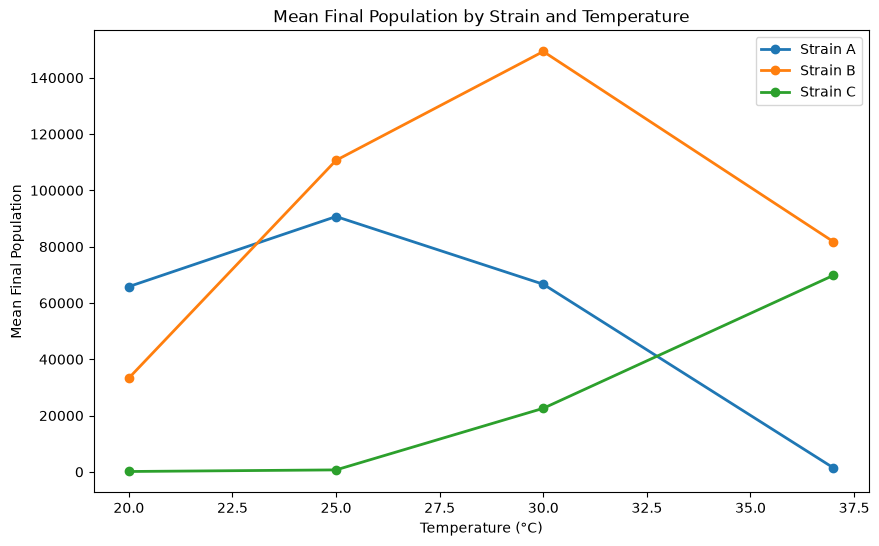

In [38]:
plt.figure(figsize=(10, 6))

for strain in experiment_group_summary["strain"].unique():
    data = experiment_group_summary[
        experiment_group_summary["strain"] == strain
    ]

    plt.plot(
        data["temperature"],
        data["mean_final_population"],
        marker="o",
        linewidth=2,
        label=f"Strain {strain}"
    )

plt.xlabel("Temperature (°C)")
plt.ylabel("Mean Final Population")
plt.title("Mean Final Population by Strain and Temperature")
plt.legend()

plt.show()

### Findings

The mean final population varies substantially across strain and
temperature combinations.

Strain A reaches its highest mean final population at 25°C, while
performance decreases substantially at 37°C.

Strain B shows its highest mean final population at 30°C, followed by
25°C and 37°C.

Strain C shows a different pattern, with its highest mean final
population occurring at 37°C.

Overall, the results indicate that the relationship between temperature
and bacterial population differs across strains. Each strain reaches its
highest observed population under a different temperature condition.

### Conclusion

The analysis indicates that bacterial population growth is strongly
associated with the combination of strain and temperature.

Each strain showed a different temperature at which its population was
highest: strain A at 25°C, strain B at 30°C, and strain C at 37°C.

These results highlight that temperature does not affect all strains in
the same way, making the interaction between strain and temperature an
important factor when comparing population growth.